In [ ]:
import dask
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr

from srm import catalog
from srm.downscaling_utils import interpolate_coarse_to_fine_grid, interpolate_fine_to_coarse_grid
from srm.qa_flags import DIR_QA_FLAG_CONSTANT_INPUTS

In [ ]:
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]

# rsds [lat, dayofyear]

Markdown was generated by Claude, then reviewed and edited.
The ceiling is built as a function of `(dayofyear, lat)`: the maximum `rsds` across all longitudes in that latitude band (a "zonal max"), taken across ERA5 and two GCMs (`CESM2-WACCM`, `UKESM`) and three scenario groups (`historical`, `g6_1p5k`, `ssp245`). Because it is the *union* of several models' and scenarios' extremes, further loosened by maxing over longitude, it is deliberately a high bar rather than a tight statistical bound. It only depends on the input data, not on which output is being checked, so it is cached rather than recomputed on every run.

This is an intentionally simpler, standalone check -- it is not connected to the rolling-window plausible-bounds check in `srm.qaqc.calculate_reasonable_bounds_doy`.

This is of dimensions [lat,dayofyear] and we are calculating a really high max bound: the maximum downwelling solar radiation at the surface across all longitudes in that zonal band, in observations and across historical and future scenarios.

This only needs to be done once. (Only needs to be rerun if the input data changes)

In [ ]:
# Generic cache helpers: write/read a DataArray to/from one zarr store, keyed by a string group name. Nothing here is specific to `rsds`.


def load_cached(key: str, fpath: str) -> xr.DataArray | None:
    """None on a cache miss; the caller decides what to do about it."""
    try:
        return xr.open_zarr(fpath, group=key)["data"].load()
    except FileNotFoundError:
        return None


def save_cached(key: str, da: xr.DataArray, fpath: str) -> None:
    da.rename("data").to_dataset().to_zarr(fpath, group=key, mode="w")

In [ ]:
def calculate_fine_gcm_zonal_limit(coarse_gcm_grid_tseries, fine_obs_doy):
    """
    For one GCM's coarse-resolution time series: reduce to a day-of-year max, regrid that onto the fine ERA5 grid with `interpolate_coarse_to_fine_grid`, then take the max across longitude to get that source's zonal day-of-year bound.
    """
    coarse_gcm_doy_grid = coarse_gcm_grid_tseries.groupby("time.dayofyear").max(dim="time")
    fine_gcm_doy_grid = interpolate_coarse_to_fine_grid(
        da_coarse_to_regrid=coarse_gcm_doy_grid, da_fine_grid=fine_obs_doy
    )
    fine_gcm_doy_zonal = fine_gcm_doy_grid.max(dim="lon")

    return fine_gcm_doy_zonal

In [ ]:
def calculate_overall_rsds_limit(
    fine_obs: xr.DataArray,
    plot_gcm_limits: bool = False,
    gcm_list: list[str] = ["CESM2-WACCM6", "UKESM1-1-LL"],
) -> xr.DataArray:
    # The same reduction applied directly to ERA5, which is already on the fine grid so no regridding step is needed.
    fine_obs_doy = fine_obs.groupby("time.dayofyear").max(dim="time")
    fine_obs_doy_zonal = fine_obs_doy.max(dim="lon")

    zonal_limit_across_all = fine_obs_doy_zonal
    # Loop over all GCMs and scenarios, regrid each to the fine grid, and take the maximum across all of them.
    # This is a way of estimating what is physically possible given variation in solar radiation by latitude and day-of-year.
    # The idea is that the highest rsds, in obs or under any ensemble member of any GCM under any scenario is a reasonable upper bound for what is physically possible.
    for gcm in gcm_list:
        print(gcm)
        for scenario in ["historical", "g6_1p5k", "ssp245"]:
            print(scenario)
            gcm_scenario = catalog.get(gcm).to_xarray()[scenario]["rsds"]

            # Combine every source into one ceiling: for each GCM x scenario combination, compute that source's zonal day-of-year max with
            # the helper function, and keep a running elementwise maximum across all of them, starting from the ERA5 value. `zonal_limit_across_all`
            # is the final ceiling, committed to the cache in the next cell.
            gcm_zonal_limit = (
                calculate_fine_gcm_zonal_limit(gcm_scenario, fine_obs_doy=fine_obs_doy)
                .max(dim="ensemble_member")
                .load()
            )

            zonal_limit_across_all = zonal_limit_across_all.where(
                (zonal_limit_across_all > gcm_zonal_limit) | gcm_zonal_limit.isnull(),
                gcm_zonal_limit,
            ).load()

            if plot_gcm_limits:
                plt.figure()
                gcm_zonal_limit.plot()
                plt.show()
    return zonal_limit_across_all

In [ ]:
# Load ERA5 as the fine reference grid: it's both the observational input to the ceiling and the common fine grid every GCM below gets regridded onto, so all sources land on the same grid before combining.

fine_obs = catalog.get("ERA5").to_xarray()["rsds"]

zonal_limit_across_all = calculate_overall_rsds_limit(
    fine_obs=fine_obs,
    plot_gcm_limits=False,
    gcm_list=["CESM2-WACCM6", "UKESM1-1-LL"],
)

save_cached(
    key="zonal_doy_max_rsds",
    da=zonal_limit_across_all,
    fpath=DIR_QA_FLAG_CONSTANT_INPUTS + "zonal_doy_max_rsds.zarr",
)

In [ ]:
zonal_limit_across_all = load_cached(
    key="zonal_doy_max_rsds", fpath=DIR_QA_FLAG_CONSTANT_INPUTS + "zonal_doy_max_rsds.zarr"
)
for gcm in ["CESM2-WACCM6", "UKESM1-1-LL"]:
    grid_example = (
        catalog.get(gcm).to_xarray()["historical"]["rsds"].isel(ensemble_member=0, time=0)
    )
    zonal_limit_across_all_gcmgrid = interpolate_fine_to_coarse_grid(
        da_fine_to_coarsen=zonal_limit_across_all, da_coarse_grid=grid_example
    )
    save_cached(
        key="zonal_doy_max_rsds",
        da=zonal_limit_across_all_gcmgrid,
        fpath=DIR_QA_FLAG_CONSTANT_INPUTS + "zonal_doy_max_rsds_" + gcm + ".zarr",
    )

Text(0, 0.5, 'Mean surface downward short-wave radiation flux [W m-2]')

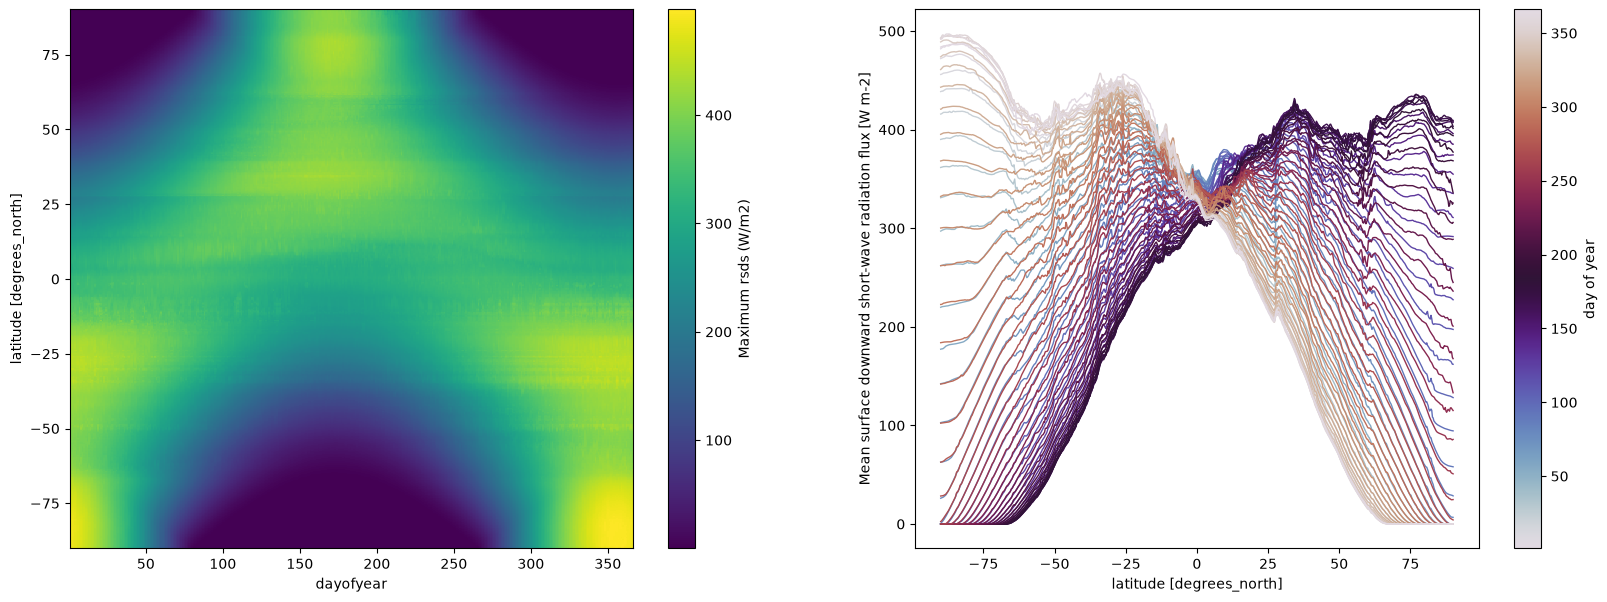

In [20]:
fig, axes = plt.subplots(figsize=(20, 7), ncols=2)

zonal_limit_across_all.transpose().plot(ax=axes[0], cbar_kwargs={"label": "Maximum rsds (W/m2)"})

ax = axes[1]
cmap = plt.get_cmap("twilight")  # cyclic: doy 1 and 366 are seasonally adjacent
norm = mpl.colors.Normalize(vmin=1, vmax=366)

for doy in zonal_limit_across_all["dayofyear"].values[::5]:
    zonal_limit_across_all.sel(dayofyear=doy).plot(
        ax=ax, color=cmap(norm(doy)), add_legend=False, linewidth=1
    )

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="day of year")
ax.set_title("")
ax.set_xlabel("latitude [degrees_north]")
ax.set_ylabel("Mean surface downward short-wave radiation flux [W m-2]")

# Outlier thresholds from obs

In [ ]:
from srm import catalog
from srm.downscaling_utils import rechunk

In [ ]:
def calculate_stats_for_outliers(obs, subset=None, timescale="annual"):
    if subset is not None:
        obs_subset = obs.sel(lat=subset[0], lon=subset[1]).load()
    else:
        obs_subset = obs

    if timescale == "annual":
        annual = obs_subset.groupby("time.year")
        obs_annual_max, obs_annual_min = dask.compute(annual.max(), annual.min())

        obs_max = obs_annual_max.max(dim=["year"])
        obs_min = obs_annual_min.min(dim=["year"])

        obs_max_std = obs_annual_max.std(dim=["year"])
        obs_min_std = obs_annual_min.std(dim=["year"])

    elif timescale == "monthly":
        monthly = obs_subset.groupby(["time.year", "time.month"])
        obs_monthly_max, obs_monthly_min = dask.compute(monthly.max(), monthly.min())

        obs_max = obs_monthly_max.max(dim="year")
        obs_min = obs_monthly_min.min(dim="year")
        obs_max_std = obs_monthly_max.std(dim="year")
        obs_min_std = obs_monthly_min.std(dim="year")

    elif timescale == "dayofyear":
        rolling_doy_max = obs_subset.rolling(time=30, center=True).max()
        rolling_doy_min = obs_subset.rolling(time=30, center=True).min()

        obs_max = rolling_doy_max.groupby("time.dayofyear").max()
        obs_min = rolling_doy_min.groupby("time.dayofyear").min()
        obs_max_std = rolling_doy_max.groupby("time.dayofyear").std()
        obs_min_std = rolling_doy_min.groupby("time.dayofyear").std()

    return [obs_max, obs_min, obs_max_std, obs_min_std]

In [ ]:
import icechunk

from srm.cache import ArtifactCache
from srm.config import _icechunk_storage_for_path


def get_regridded_obs(
    gcm: str,
    variable: str,
    branch: str,
    obs_dataset: str = "ERA5",
    subset_bounds: tuple[float, float, float, float] | None = None,
    scratch_dir: str = "s3://carbonplan-srm/scratch/cache/",
    environment: str = "qa",
) -> xr.DataArray:
    """
    Read `variable`'s already-cached obs, regridded onto `gcm`'s coarse grid.

    This is the artifact BCSDPipeline.prepare_observations (pipeline.py) writes via
    ArtifactCache.obs_loc (cache.py) -- reading it here avoids re-running
    interpolate_fine_to_coarse_grid from scratch every time.

    Deliberately does not go through BCSDRun.obs / load_cached_data (analysis.py):
    that path opens the icechunk store without passing `group=` to
    xr.open_dataset, but the store obs_loc points at is shared across many nested
    zarr groups (obs/{variable}, plus historical/scenario output under other
    prefixes in the same repo for the output store's case) -- so it does not
    reliably select just this variable's data. This function opens the
    "obs/{variable}" group explicitly instead.

    Parameters
    ----------
    gcm : str
        GCM name, e.g. "CESM2-WACCM6" -- the coarse grid the obs were regridded
        onto; part of the cache store's path (alongside obs_dataset and subset).
    variable : str
        Variable to read, e.g. "tas" -- selects the "obs/{variable}" group.
    branch : str
        icechunk branch to read, e.g. the pipeline run's cache version
        (``BCSD_BRANCH``/``_cache_version`` in bcsd_config.py) that wrote this
        artifact, such as ``"v0.14.0"``.
    obs_dataset : str
        Name of the observational dataset that was regridded, e.g. "ERA5".
    subset_bounds : tuple(lat_min, lat_max, lon_min, lon_max) or None
        Spatial subset the cache was built for; None (default) means the global
        store, matching ArtifactCache._get_subset_id's "global" default.
    scratch_dir, environment : str
        Cache location; defaults match ArtifactCache's own defaults.

    Returns
    -------
    xr.DataArray
        The cached regridded obs for `variable`, still lazy (dask-backed) and with
        its full time dimension intact -- interpolate_fine_to_coarse_grid only
        touches lat/lon, so no reduction has happened at this stage.
    """
    subset_id = ArtifactCache._get_subset_id(subset_bounds)
    store_path = f"{scratch_dir.rstrip('/')}/{environment}/{gcm}-{obs_dataset}-{subset_id}.icechunk"
    repo = icechunk.Repository.open(_icechunk_storage_for_path(store_path))
    session = repo.readonly_session(branch)
    ds = xr.open_dataset(session.store, engine="zarr", consolidated=False, group=f"obs/{variable}")
    return ds[variable]

### Load obs

In [ ]:
# Fine-scale obs

obs = catalog.get("ERA5").to_xarray()
obs = obs[VARIABLES]

obs_fine = xr.Dataset(
    {var: rechunk(da=obs[var], pattern="full_time") for var in obs.data_vars},
    attrs=obs.attrs,
)

##### Annual stats

In [ ]:
# Fine observations

[obs_max, obs_min, obs_max_std, obs_min_std] = calculate_stats_for_outliers(
    obs=obs_fine, subset=None, timescale="annual"
)

combined = xr.merge(
    [
        obs_max.rename({v: f"{v}_max" for v in obs_max.data_vars}),
        obs_min.rename({v: f"{v}_min" for v in obs_min.data_vars}),
        obs_max_std.rename({v: f"{v}_max_std" for v in obs_max_std.data_vars}),
        obs_min_std.rename({v: f"{v}_min_std" for v in obs_min_std.data_vars}),
    ]
)

combined.to_zarr(DIR_QA_FLAG_CONSTANT_INPUTS + "annual_obs_thresholds_global.zarr", mode="w")

In [ ]:
var_list = ["tas", "tasmax", "tasmin", "pr", "rsds"]

for gcm in ["CESM2-WACCM6", "UKESM1-1-LL"]:
    print(gcm)

    print("Loading cached regridded obs")
    obs_coarse_gcm = xr.Dataset(
        {
            var: get_regridded_obs(
                gcm=gcm,
                variable=var,
                branch="v0.14.1",
                obs_dataset="ERA5",
                subset_bounds=None,
                scratch_dir="s3://carbonplan-srm/scratch/cache/",
                environment="production",
            )
            for var in var_list
        }
    )

    obs_coarse_gcm = xr.Dataset(
        {
            var: rechunk(da=obs_coarse_gcm[var], pattern="full_time")
            for var in obs_coarse_gcm.data_vars
        },
        attrs=obs_coarse_gcm.attrs,
    )

    print("Calculating outliers")
    [obs_max_gcm, obs_min_gcm, obs_max_std_gcm, obs_min_std_gcm] = calculate_stats_for_outliers(
        obs=obs_coarse_gcm, subset=None, timescale="annual"
    )

    print("Writing out data")
    combined = xr.merge(
        [
            obs_max_gcm.rename({v: f"{v}_max" for v in obs_max_gcm.data_vars}),
            obs_min_gcm.rename({v: f"{v}_min" for v in obs_min_gcm.data_vars}),
            obs_max_std_gcm.rename({v: f"{v}_max_std" for v in obs_max_std_gcm.data_vars}),
            obs_min_std_gcm.rename({v: f"{v}_min_std" for v in obs_min_std_gcm.data_vars}),
        ]
    )

    combined.to_zarr(
        DIR_QA_FLAG_CONSTANT_INPUTS + "annual_obs_thresholds_global_" + gcm + ".zarr", mode="w"
    )

##### Day of year stats

In [ ]:
[obs_max, obs_min, obs_max_std, obs_min_std] = calculate_stats_for_outliers(
    obs=obs_fine, subset=None, timescale="dayofyear"
)

stats = {"max": obs_max, "min": obs_min, "max_std": obs_max_std, "min_std": obs_min_std}

# Sometimes this crashes after a few variables -- works if you rerun
STORE = DIR_QA_FLAG_CONSTANT_INPUTS + "doy_obs_thresholds_global.zarr"

for i, var in enumerate(VARIABLES):
    print(var)
    per_var = xr.merge(
        [
            stats["max"][[var]].rename({var: f"{var}_max"}),
            stats["min"][[var]].rename({var: f"{var}_min"}),
            stats["max_std"][[var]].rename({var: f"{var}_max_std"}),
            stats["min_std"][[var]].rename({var: f"{var}_min_std"}),
        ]
    )
    mode = "w" if i == 0 else "a"
    per_var.to_zarr(STORE, mode=mode)

In [ ]:
for gcm in ["CESM2-WACCM6", "UKESM1-1-LL"]:
    print(gcm)

    print("Loading cached regridded obs")
    obs_coarse_gcm = xr.Dataset(
        {
            var: get_regridded_obs(
                gcm=gcm,
                variable=var,
                branch="v0.14.1",
                obs_dataset="ERA5",
                subset_bounds=None,
                scratch_dir="s3://carbonplan-srm/scratch/cache/",
                environment="production",
            )
            for var in var_list
        }
    )

    obs_coarse_gcm = xr.Dataset(
        {
            var: rechunk(da=obs_coarse_gcm[var], pattern="full_time")
            for var in obs_coarse_gcm.data_vars
        },
        attrs=obs_coarse_gcm.attrs,
    )

    [obs_max_gcm, obs_min_gcm, obs_max_std_gcm, obs_min_std_gcm] = calculate_stats_for_outliers(
        obs=obs_coarse_gcm, subset=None, timescale="dayofyear"
    )

    stats_gcm = {
        "max": obs_max_gcm,
        "min": obs_min_gcm,
        "max_std": obs_max_std_gcm,
        "min_std": obs_min_std_gcm,
    }

    gcm_store = DIR_QA_FLAG_CONSTANT_INPUTS + "doy_obs_thresholds_global_" + gcm + ".zarr"

    for i, var in enumerate(var_list):
        print(var)
        per_var = xr.merge(
            [
                stats_gcm["max"][[var]].rename({var: f"{var}_max"}),
                stats_gcm["min"][[var]].rename({var: f"{var}_min"}),
                stats_gcm["max_std"][[var]].rename({var: f"{var}_max_std"}),
                stats_gcm["min_std"][[var]].rename({var: f"{var}_min_std"}),
            ]
        )
        mode = "w" if i == 0 else "a"
        per_var.to_zarr(gcm_store, mode=mode)

# Day of years where climatology goes below tiny threshold

In [ ]:
from srm.bcsd_config import VariableConfig
from srm.downscaling_utils import calculate_doy_means

fine_obs = catalog.get("ERA5").to_xarray()

store = DIR_QA_FLAG_CONSTANT_INPUTS + "doy_below_tiny_threshold.zarr"

for i, var in enumerate(["pr", "rsds"]):
    var_clim_fine_obs = calculate_doy_means(
        da=fine_obs[var],
        clim_method="fft",
        allow_negative_values=False,
    )

    cfg = VariableConfig.for_variable(var, "BCSD")
    tiny_thresh = cfg.disaggregation_tiny_threshold
    flag_doy = (var_clim_fine_obs <= tiny_thresh).rename(f"{var}_below_tiny_thresh")

    flag_doy.to_zarr(store, mode="w" if i == 0 else "a")